# Experiment Optimization

With the experiment simulator built and a couple datasets to test on, let's now explore the relationship between experimental parameters and experiment quality.

Experiment quality in this context is primarily the correlation between the measured proxy (enrichment score) and the true phenotype of interest (ddG bind). However, some other metrics of interest include:
- Data waste
    - i.e. What fraction of data do we toss because it doesn't meet the min read count threshold?
- Sensitivity in range of interest
    - i.e. How well can it distinguish between binder strength from 5-200 nM (our immunity zone of interest)?

First, we need a function to run experiments and collect correlation metrics, then plot the results.

In [26]:
import pandas as pd
from scipy.stats import spearmanr, linregress

from scripts.simulator import simulate_experiment

def compute_metrics(exp_df: pd.DataFrame, read_count_threshold):
    results = {}

    # Calculate data waste
    # Determine initial number of unique variants present in library reads
    filt_df = exp_df.copy()
    filt_df = filt_df.loc[filt_df.lib_read_counts > 0]
    n_unique_init = filt_df.aa_substitutions.nunique()

    # Determine number of unique variants after filtering by threshold
    filt_df = filt_df.loc[filt_df.lib_read_counts > read_count_threshold]
    n_unique_filt = filt_df.aa_substitutions.nunique()

    results['data_waste'] = 1 - (n_unique_filt / n_unique_init)

    # Calculate enrichment scores
    wt_lib = filt_df.loc[filt_df.aa_substitutions == '', 'lib_read_counts'].sum()
    wt_sort = filt_df.loc[filt_df.aa_substitutions == '', 'sort_read_counts'].sum()
    filt_df['enrichment'] = np.log2(((filt_df.sort_read_counts + 1) / (wt_sort + 1))/((exp_df.lib_read_counts + 1) / (wt_lib + 1)))

    # Calculate correlation between enrichment and ddG_bind
    rho, _ = spearmanr(filt_df['enrichment'], filt_df['ddG_bind'])
    results['spearmanr_all'] = rho

    # Calculate sensitivity and correlation within Kd range of interest
    filt_df = filt_df.loc[filt_df.Kd_variant < 200e-9]

    rho, _ = spearmanr(filt_df['enrichment'], filt_df['ddG_bind'])
    results['spearmanr_bio'] = rho

    slope, intercept, r_value, p_value, std_err = linregress(
        filt_df['ddG_bind'], 
        filt_df['enrichment']
    )

    results['sensitivity'] = slope

    return results


def screen_parameter(
    df,
    param_to_optimize,
    values_to_test,
    params_dict,
    read_count_threshold = 9,
    n_replicates = 1
):

    results = []

    for val in values_to_test:
        current_params = params_dict.copy()
        current_params[param_to_optimize] = val

        for rep in range(n_replicates):
            exp_df = simulate_experiment(df, **current_params)

            exp_results = compute_metrics(exp_df, read_count_threshold)
            exp_results[param_to_optimize] = val
            exp_results['replicate'] = rep
            results.append(exp_results)

    return pd.DataFrame(results)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_optimization_results(results_df, param_name, log_x=True):
    """
    Plots the outputs of screen_parameter in a 2x2 grid.
    Aggregates replicates showing Mean (Line) +/- Std Dev (Shaded Area).
    """
    # Set style
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    
    # Create 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Optimization of Parameter: {param_name}', fontsize=16, y=1.02)
    
    # Flatten axes for easy iteration
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    # Common plotting kwargs
    # errorbar='sd' draws the standard deviation. 
    # err_style='band' draws the shaded region (default).
    plot_kws = {'x': param_name, 'data': results_df, 'marker': 'o', 'errorbar': 'sd'}

    # --- PLOT 1: Global Spearman Correlation ---
    sns.lineplot(y='spearmanr_all', ax=ax1, color='C0', **plot_kws)
    ax1.set_title('Global Correlation (All Variants)', fontweight='bold')
    ax1.set_ylabel("Spearman's ρ (Mean ± SD)")

    # --- PLOT 2: Biological Range Correlation ---
    sns.lineplot(y='spearmanr_bio', ax=ax2, color='C1', **plot_kws)
    ax2.set_title('Target Range Correlation (Kd < 200nM)', fontweight='bold')
    ax2.set_ylabel("Spearman's ρ (Mean ± SD)")

    # --- PLOT 3: Sensitivity (Slope) ---
    sns.lineplot(y='sensitivity', ax=ax3, color='C2', **plot_kws)
    ax3.set_title('Assay Sensitivity (Slope)', fontweight='bold')
    ax3.set_ylabel("Slope (Enrichment / ddG)")
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)

    # --- PLOT 4: Data Waste (Dropout Rate) ---
    sns.lineplot(y='data_waste', ax=ax4, color='C3', **plot_kws)
    ax4.set_title('Data Waste (Dropout Rate)', fontweight='bold')
    ax4.set_ylabel("Fraction of Library Lost")
    ax4.set_ylim(-0.05, 1.05) 

    # Handle Log Scale
    if log_x:
        for ax in axes.flatten():
            ax.set_xscale('log')

    plt.tight_layout()
    return fig

In [28]:
# Load ground truth data
gb1_df = pd.read_csv("datasets/gb1/gb1_full_library_ddG.csv")

# Default parameters reflecting our default experimental conditions
params = {
    'num_cells_sorted': 1e8,
    'RT': 0.001987 * 298.15,
    'wt_dG_fold': -4.8,
    'wt_dG_bind': -9.0,
    'ligand_conc': 100e-9,
    'hill_coeff': 1.0,
    't_exp': 0.9,
    't_bind': 0.95,
    'facs_noise': 0.5,
    'miniprep_input_cells': 4e7,
    'plasmid_copy_number': 1,
    'miniprep_efficiency': 0.0016,
    'elution_vol': 10,
    'template_vol': 1,
    'pcr_cycles': 25,
    'pcr_efficiency': 0.9,
    'pcr_noise': 1.5,
    'seq_depth': 350_000
}

/tmp/ipykernel_4541/4161353688.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


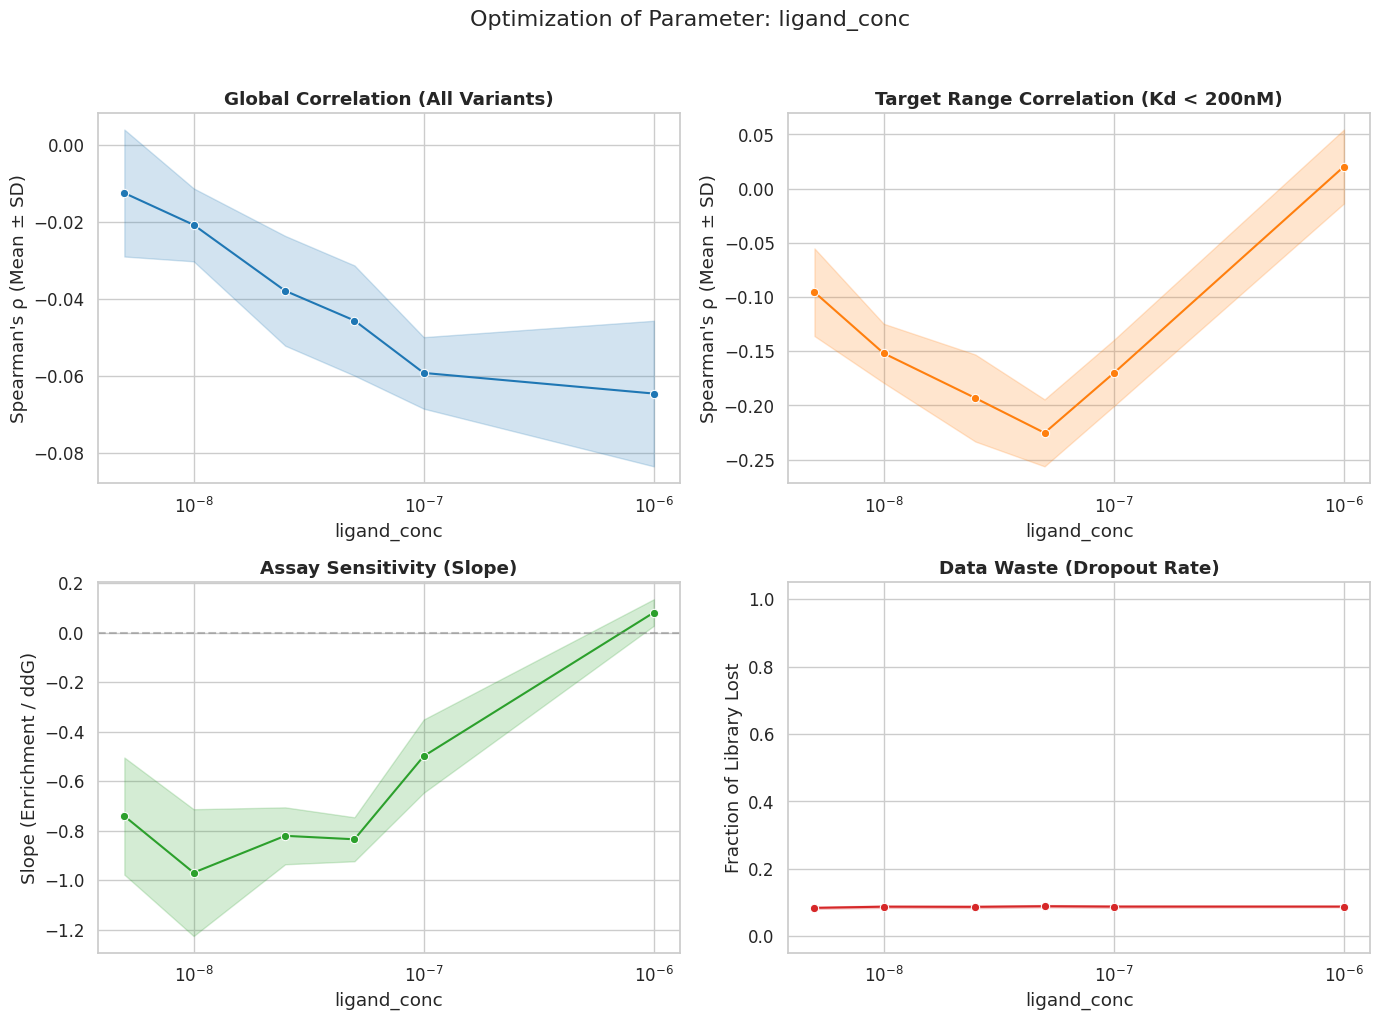

In [29]:
param_to_optimize = "ligand_conc"
vals_to_test = [1000e-9, 100e-9, 50e-9, 25e-9, 10e-9, 5e-9]

ligand_df = screen_parameter(gb1_df, param_to_optimize, vals_to_test, params, n_replicates=10)
fig = plot_optimization_results(ligand_df, param_to_optimize, log_x=True)
fig.show()

/tmp/ipykernel_4541/4037522408.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


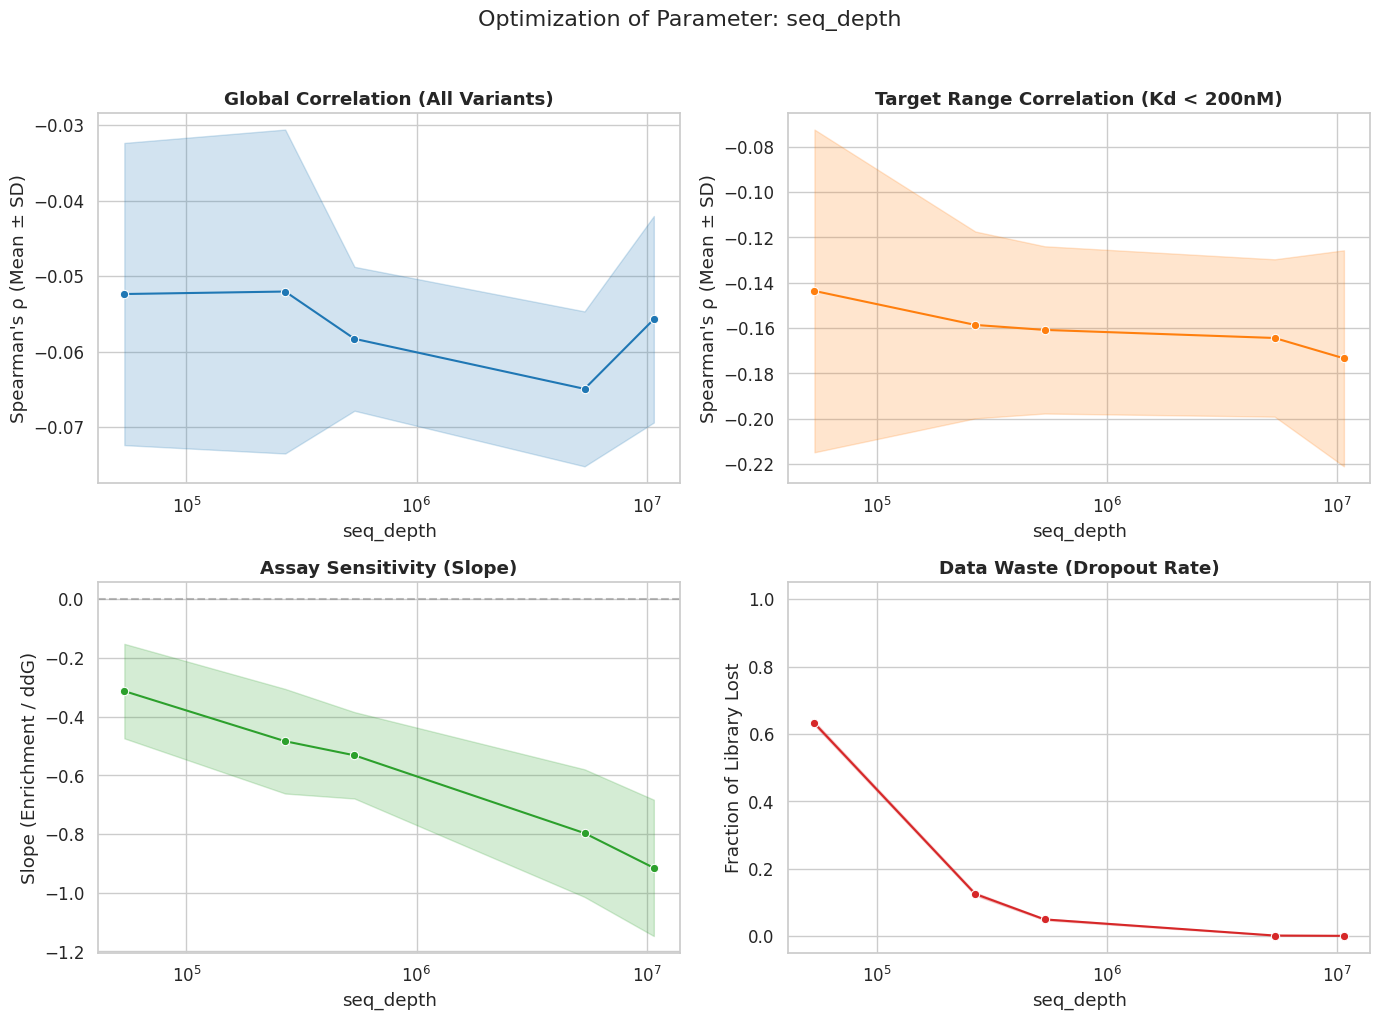

In [30]:
param_to_optimize = "seq_depth"
vals_to_test = [len(gb1_df) * 20, len(gb1_df) * 10, len(gb1_df) * 1, int(len(gb1_df) * .5), int(len(gb1_df) * .1)]

ligand_df = screen_parameter(gb1_df, param_to_optimize, vals_to_test, params, n_replicates=10)
fig = plot_optimization_results(ligand_df, param_to_optimize, log_x=True)
fig.show()

/tmp/ipykernel_4541/4293767149.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


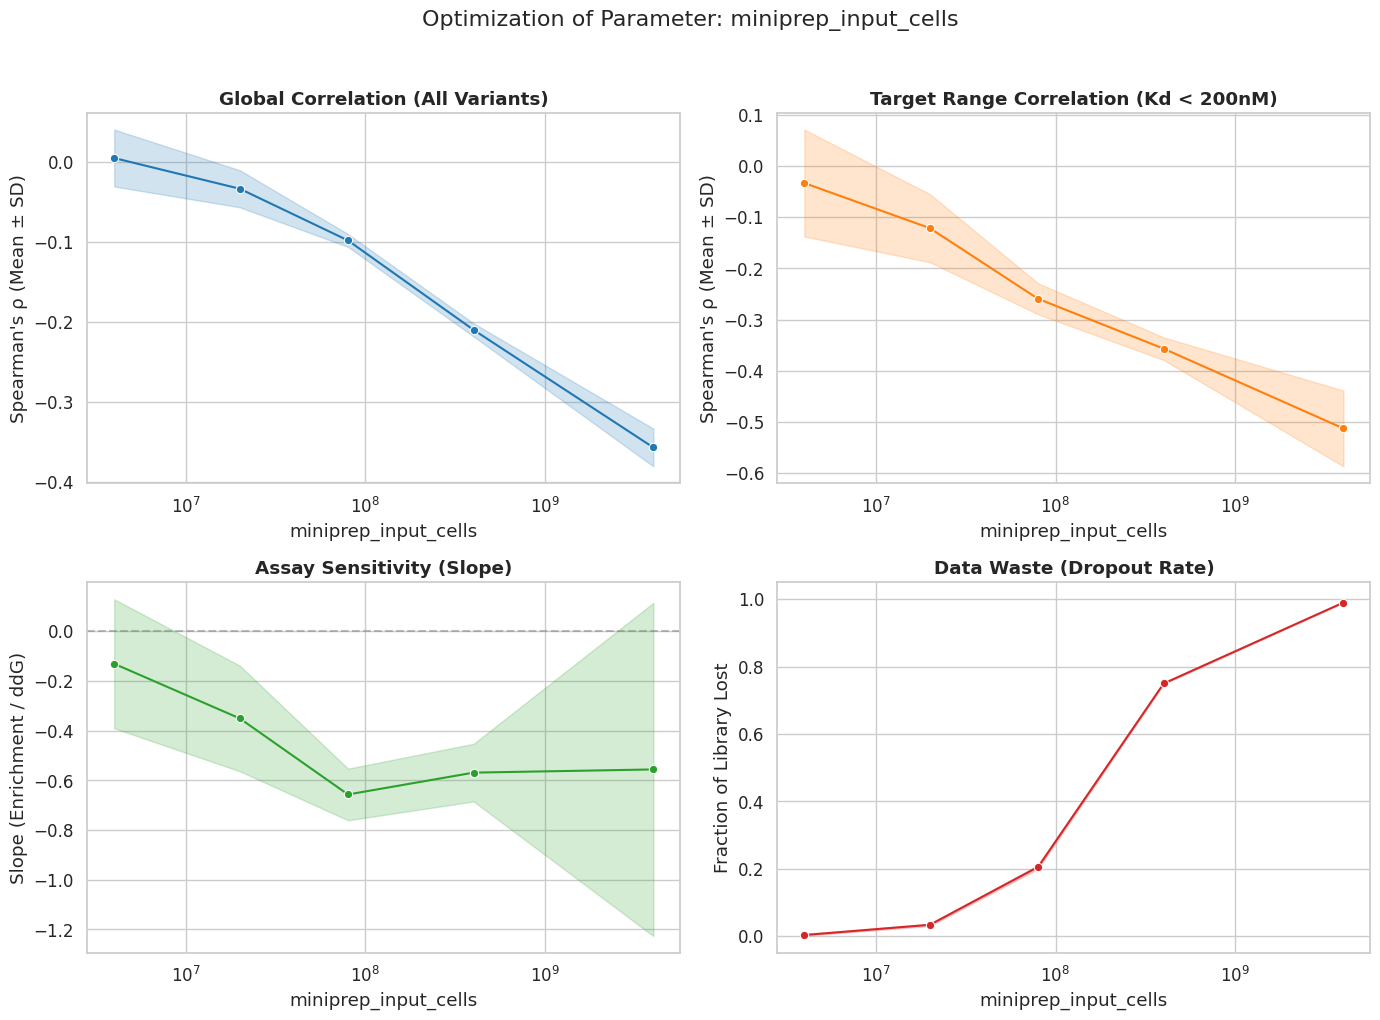

In [32]:
param_to_optimize = "miniprep_input_cells"
vals_to_test = [100, 10, 2, 0.5, 0.1]
vals_to_test = list(map(lambda x: int(x * params['miniprep_input_cells']), vals_to_test))

ligand_df = screen_parameter(gb1_df, param_to_optimize, vals_to_test, params, n_replicates=10)
fig = plot_optimization_results(ligand_df, param_to_optimize, log_x=True)
fig.show()

In [36]:
# Special set up to test library subsampling prior to experimentation
subsample_ratios = [1, 0.5, 0.25, 0.1, 0.05]
results = []

for ratio in subsample_ratios:
    subsample_df = gb1_df.sample(frac=ratio)

    # setup dummy optmization
    param_to_optimize = "seq_depth"
    vals_to_test = [params[param_to_optimize]]

    result_df = screen_parameter(subsample_df, param_to_optimize, vals_to_test, params, n_replicates=10)
    result_df['subsample_ratio'] = ratio
    results.append(result_df)

results_df = pd.concat(results, axis=0)
results_df


,data_waste,spearmanr_all,spearmanr_bio,sensitivity,seq_depth,replicate,subsample_ratio
0,0.095964,-0.061803,-0.160526,-0.682750,350000,0,1.00
1,0.089077,-0.064424,-0.256980,-0.738831,350000,1,1.00
2,0.091423,-0.053833,-0.122637,-0.321986,350000,2,1.00
3,0.088922,-0.053311,-0.246683,-0.483728,350000,3,1.00
4,0.093020,-0.055064,-0.149899,-0.378229,350000,4,1.00
5,0.077837,-0.042749,-0.178708,-0.511600,350000,5,1.00
6,0.084369,-0.073414,-0.090821,-0.501216,350000,6,1.00
7,0.088576,-0.054699,-0.139427,-0.435048,350000,7,1.00
8,0.085811,-0.039068,-0.126708,-0.242565,350000,8,1.00
9,0.085710,-0.059855,-0.180923,-0.369688,350000,9,1.00


/tmp/ipykernel_4541/1825464956.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


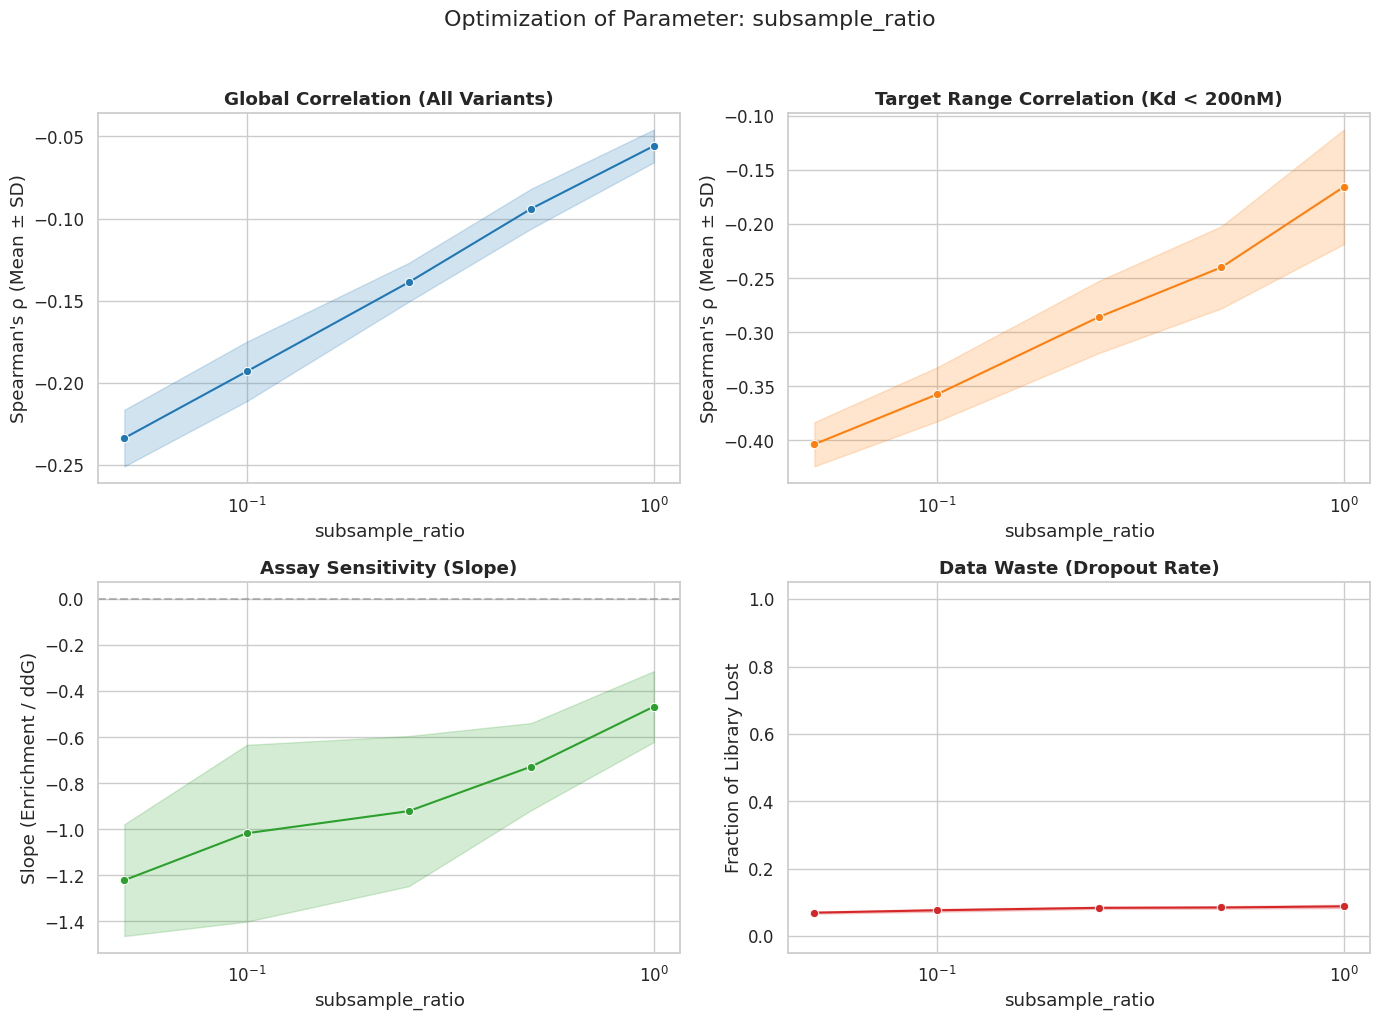

In [37]:
fig = plot_optimization_results(results_df, "subsample_ratio", log_x=True)
fig.show()

In [39]:
# Special set up to test read count thresholds
thresholds = [100, 50, 20, 10, 8, 4, 3]
results = []

for thresh in thresholds:
    # setup dummy optmization
    param_to_optimize = "seq_depth"
    vals_to_test = [params[param_to_optimize]]

    result_df = screen_parameter(subsample_df, param_to_optimize, vals_to_test, params, read_count_threshold = thresh, n_replicates=10)
    result_df['threshold'] = thresh
    results.append(result_df)

results_df = pd.concat(results, axis=0)
results_df

,data_waste,spearmanr_all,spearmanr_bio,sensitivity,seq_depth,replicate,threshold
0,0.758081,-0.267840,-0.430383,-1.285032,350000,0,100
1,0.761409,-0.266868,-0.450661,-0.725348,350000,1,100
2,0.757620,-0.300048,-0.353961,-0.714634,350000,2,100
3,0.762210,-0.295360,-0.415389,-1.242118,350000,3,100
4,0.773244,-0.230058,-0.349851,-0.592430,350000,4,100
...,...,...,...,...,...,...,...
5,0.018706,-0.227542,-0.373797,-0.769512,350000,5,3
6,0.018492,-0.233368,-0.415956,-1.304792,350000,6,3
7,0.020768,-0.245942,-0.313314,-0.716218,350000,7,3
8,0.018257,-0.254552,-0.421683,-1.345341,350000,8,3


/tmp/ipykernel_4541/760874622.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


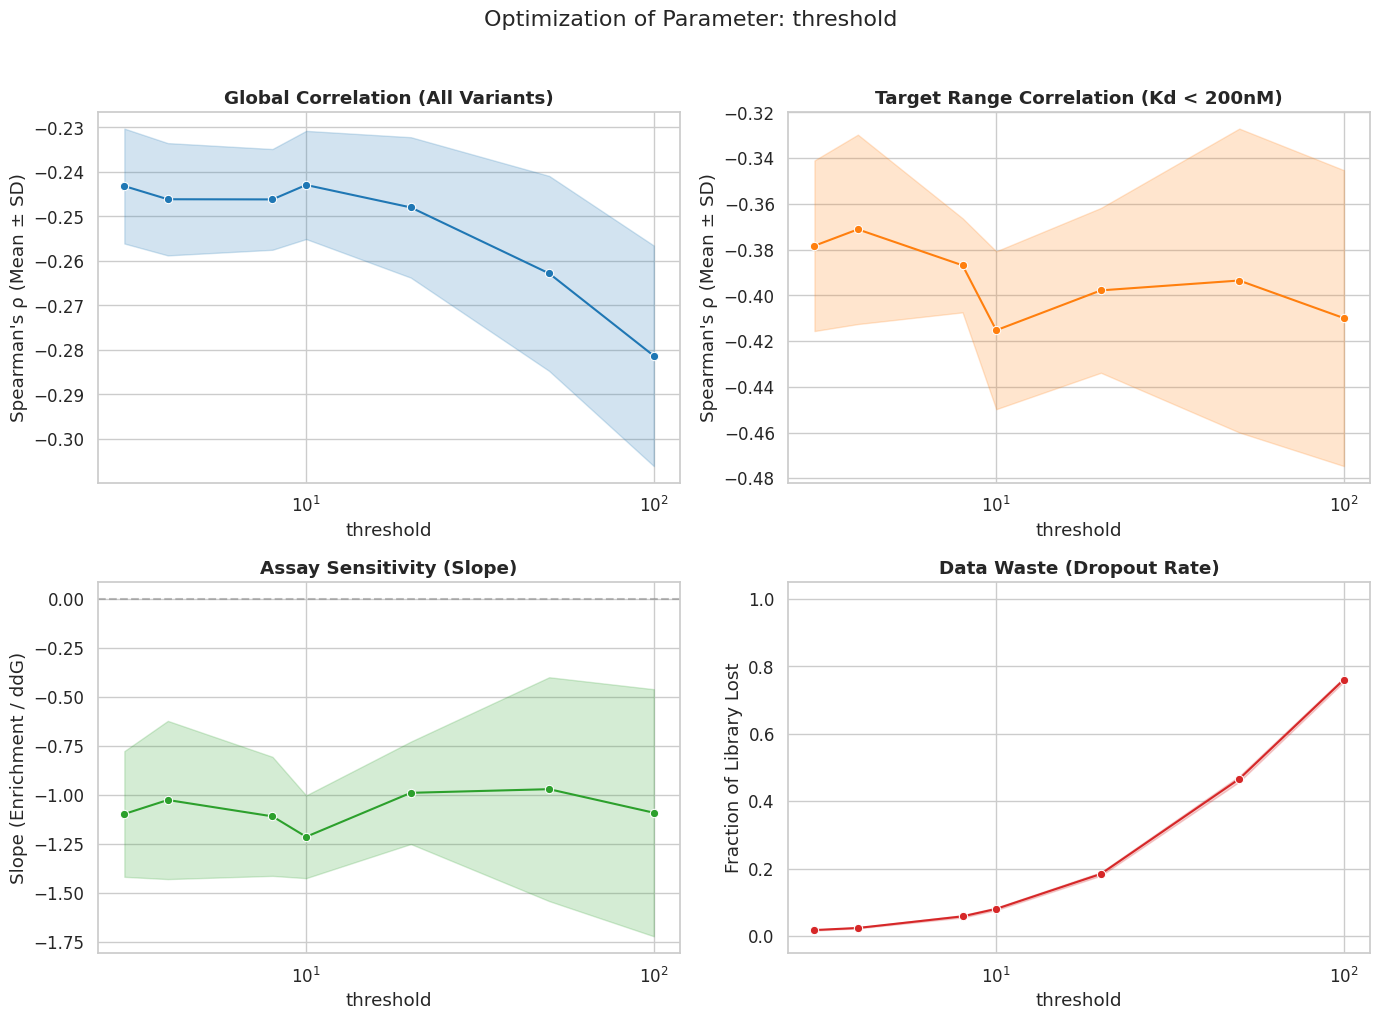

In [40]:
fig = plot_optimization_results(results_df, "threshold", log_x=True)
fig.show()